In [59]:
import pandas as pd

In [60]:
df=pd.read_csv("placement (1).csv")

In [61]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


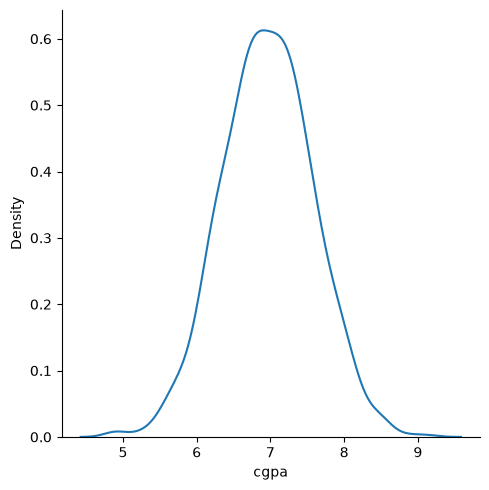

In [62]:
import seaborn as sns
sns.displot(df["cgpa"],kind="kde")

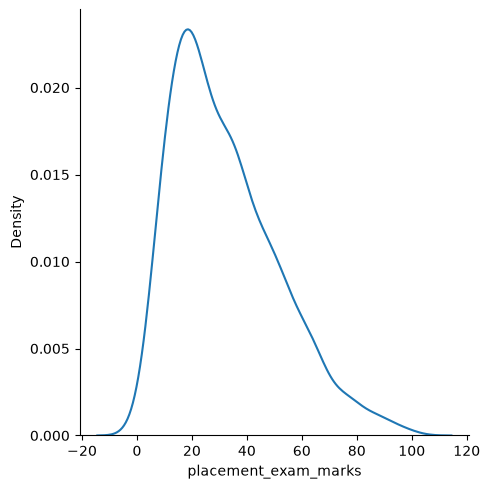

In [63]:
sns.displot(df["placement_exam_marks"],kind="kde")

In [64]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [65]:
# CGPA is normally distributed.
# finding boundary values ---> mean + 3 * S.D , mean - 3 * S.D

max= 6.961240 + 3*0.615898
min=6.961240 - 3*0.615898

In [66]:
min

5.113546

In [67]:
max

8.808934

In [68]:
# viewing outliers
df[(df["cgpa"] < 5.11) | (df["cgpa"] > 8.8)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [69]:
# TRIMMING M1

new_df=df[(df["cgpa"] > 5.11) & (df["cgpa"] < 8.8)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [70]:
# TRIMMING M2
# CGPA is normally distributed.

mean = df["cgpa"].mean()
sd = df["cgpa"].std()

df["cgpa_zscore"] = (df["cgpa"] - mean) / sd

In [71]:
df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [72]:
df[(df["cgpa_zscore"]>3) | (df["cgpa_zscore"]<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [73]:
new_df=df[(df["cgpa_zscore"]<3) & (df["cgpa_zscore"]>-3)]

In [74]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


CAPPING

In [ ]:
# IMPORTANT
import numpy as np
df["cgpa_capped"]=np.where(
    df["cgpa"]>max,
    max,
    np.where(
        df["cgpa"]<min,
        min,
        df["cgpa"]
    )
)

In [76]:
df

,cgpa,placement_exam_marks,placed,cgpa_zscore,cgpa_capped
0,7.19,26.0,1,0.371425,7.190000
1,7.46,38.0,1,0.809810,7.460000
2,7.54,40.0,1,0.939701,7.540000
3,6.42,8.0,1,-0.878782,6.420000
4,7.23,17.0,0,0.436371,7.230000
...,...,...,...,...,...
995,8.87,44.0,1,3.099150,8.808934
996,9.12,65.0,1,3.505062,8.808934
997,4.89,34.0,0,-3.362960,5.113546
998,8.62,46.0,1,2.693239,8.620000


# SOLVING USING IQR
(placement_exam_marks is skewed)

In [79]:
# calculating percentile and IQR

perc25=df["placement_exam_marks"].quantile(0.25)
perc75=df["placement_exam_marks"].quantile(0.75)

IQR= perc75-perc25
IQR

np.float64(27.0)

In [ ]:
# calculating max and min

min=perc25-1.5*IQR
max=perc75+1.5*IQR

TRIMMING

In [80]:
new_df=df[(df["cgpa"] > min) & (df["cgpa"] < max)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore,cgpa_capped
0,7.19,26.0,1,0.371425,7.19
1,7.46,38.0,1,0.809810,7.46
2,7.54,40.0,1,0.939701,7.54
3,6.42,8.0,1,-0.878782,6.42
4,7.23,17.0,0,0.436371,7.23
...,...,...,...,...,...
991,7.04,57.0,0,0.127878,7.04
992,6.26,12.0,0,-1.138565,6.26
993,6.73,21.0,1,-0.375452,6.73
994,6.48,63.0,0,-0.781363,6.48


CAPPING

In [82]:
df["marks_capped"]=np.where(
    df["placement_exam_marks"]>max,
    max,
    np.where(
        df["placement_exam_marks"]<min,
        min,
        df["placement_exam_marks"]
    )
)
df

,cgpa,placement_exam_marks,placed,cgpa_zscore,cgpa_capped,marks_capped
0,7.19,26.0,1,0.371425,7.190000,8.808934
1,7.46,38.0,1,0.809810,7.460000,8.808934
2,7.54,40.0,1,0.939701,7.540000,8.808934
3,6.42,8.0,1,-0.878782,6.420000,8.000000
4,7.23,17.0,0,0.436371,7.230000,8.808934
...,...,...,...,...,...,...
995,8.87,44.0,1,3.099150,8.808934,8.808934
996,9.12,65.0,1,3.505062,8.808934,8.808934
997,4.89,34.0,0,-3.362960,5.113546,8.808934
998,8.62,46.0,1,2.693239,8.620000,8.808934
